# RealLift Demonstration: DoE - Design of Experiments

## 1. Installation

In [ ]:
# From GitHub
# %pip install git+https://github.com/RobertoJuniorWXYZ/RealLift.git
# or
# From PyPI
%pip install reallift

## 2. Generate Simulated Data

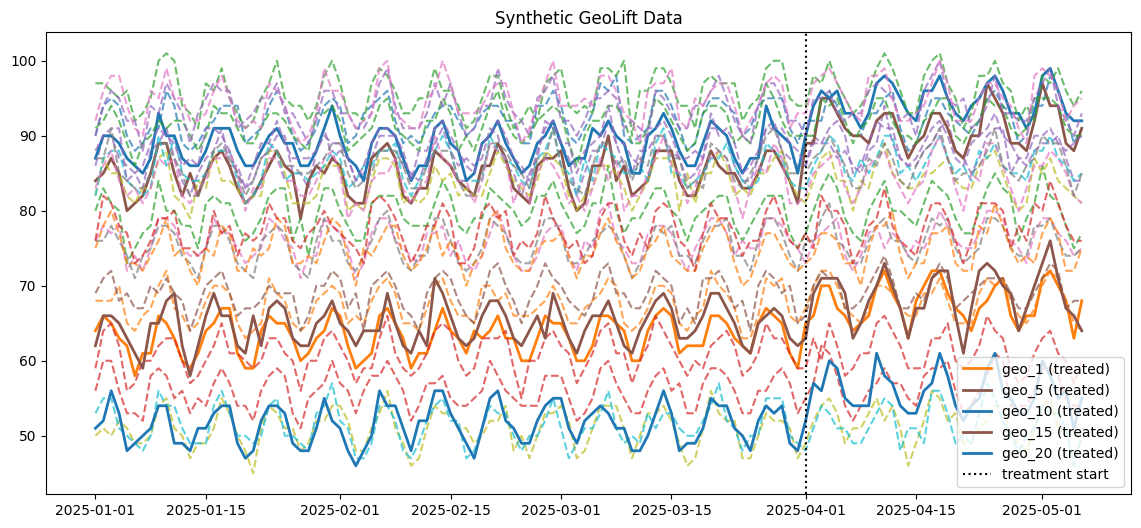

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from reallift import generate_geolift_data

# Parameters for simulation
file_pre_test = 'demo_geodata_pre_test.csv'
file_post_test = 'demo_geodata_post_test.csv'
start_date = "2025-01-01"
treatment_start = "2025-04-01"
end_date = pd.to_datetime(treatment_start) + pd.Timedelta(days=35)

df, df_pre, treated = generate_geolift_data(
    start_date = start_date,
    treatment_start = treatment_start,
    end_date = end_date,
    n_geos=27,
    treatment_geos=["geo_1","geo_5","geo_10","geo_15","geo_20"],
    lift=[0.05, 0.09],  # lift post test
    trend_slope=0.01,
    seasonality_amplitude=3,
    seasonality_period=7,
    noise_std=[1, 1.5],
    save_csv=True,
    file_name=file_post_test,
    pre_file_name=file_pre_test,
    base_value=[50, 100],
    as_integer=True,
    random_seed=42
)

## GEO Experiment Pipeline
### GEO Experiment Execution (`run_geo_experiment`)
Runs the complete GeoLift end-to-end pipeline: identifies clusters, validates the pre-test period, estimates duration requirements, calculates the final impact using Synthetic Control, and performs Placebo tests for statistical significance.

**Key Options:**
- `treatment_start_date`: The exact date the intervention (e.g., campaign) started.
- `n_treatment`: Number of Geos to be selected for the Treatment group.
- `fixed_treatment`: List of specific Geos to be forced into the Treatment group.
- `mde`: Minimum Detectable Effect used for duration and power analysis.
- `n_folds`: Number of divisions for Cross-Validation stability check.
- `plot`: If `True`, generates visual charts for Synthetic Control alignment and Placebo distributions.

> [!IMPORTANT]
> **Recommendation:** Ensure the `treatment_start_date` aligns precisely with the start of your marketing intervention. For valid results, the pre-treatment period should show a high R² and low MAPE during validation.

**What it does:** It executes the full analytical flow: finding optimal splits, validating stability, estimating requirements, and then calculating the actual Lift. It uses `run_synthetic_control` to build a counterfactual and `run_placebo_tests` to determine the probability that the observed effect was not just due to random chance.


In [2]:
from reallift.pipelines.geo_pipeline import run_geo_experiment

results = run_geo_experiment(
    filepath=file_post_test,
    date_col='date',
    treatment_start_date=treatment_start,
    geos=None,
    n_treatment=5,
    fixed_treatment=["geo_1","geo_5","geo_10","geo_15","geo_20"],
    mde=0.015,
    max_days=[21, 60],
    plot=False,
    verbose=True,
    n_folds=5,
    random_state=42
)


=== BEST CLUSTERS FOUND ===
Cluster 0: Treatment ['geo_10'], Correlation 0.8419
Cluster 1: Treatment ['geo_5'], Correlation 0.8059
Cluster 2: Treatment ['geo_1'], Correlation 0.7941
Cluster 3: Treatment ['geo_20'], Correlation 0.8048
Cluster 4: Treatment ['geo_15'], Correlation 0.7417

=== CLUSTER 0 ===

=== GEO CLUSTER VALIDATION (Cluster 0) ===
Treatment: ['geo_10']
Control: ['geo_0', 'geo_2', 'geo_6', 'geo_12', 'geo_14', 'geo_16', 'geo_17', 'geo_18', 'geo_19', 'geo_22', 'geo_24', 'geo_25']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.8903 | Average OOF R2: 0.7821
Average Train MAPE: 0.0066 | Average OOF MAPE: 0.0103
Average Train WAPE: 0.0066 | Average OOF WAPE: 0.0103

=== GEO DURATION ESTIMATION (Cluster 0) ===
Treatment: ['geo_10']
Control: ['geo_0', 'geo_2', 'geo_6', 'geo_12', 'geo_14', 'geo_16', 'geo_17', 'geo_18', 'geo_19', 'geo_22', 'geo_24', 'geo_25']

=== EVALUATING PERIOD ===
Sta